<a href="https://colab.research.google.com/github/Sneekyboots/Perkinsons-Disease-Prediction-Model/blob/main/Perkinsons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading and gathering all the features**

In [5]:
import pandas as pd

data = pd.read_csv('/content/pd_speech_features.csv')

features = data.columns.tolist()
print(features)


['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter', 'locAbsJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter', 'locShimmer', 'locDbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'meanAutoCorrHarmonicity', 'meanNoiseToHarmHarmonicity', 'meanHarmToNoiseHarmonicity', 'minIntensity', 'maxIntensity', 'meanIntensity', 'f1', 'f2', 'f3', 'f4', 'b1', 'b2', 'b3', 'b4', 'GQ_prc5_95', 'GQ_std_cycle_open', 'GQ_std_cycle_closed', 'GNE_mean', 'GNE_std', 'GNE_SNR_TKEO', 'GNE_SNR_SEO', 'GNE_NSR_TKEO', 'GNE_NSR_SEO', 'VFER_mean', 'VFER_std', 'VFER_entropy', 'VFER_SNR_TKEO', 'VFER_SNR_SEO', 'VFER_NSR_TKEO', 'VFER_NSR_SEO', 'IMF_SNR_SEO', 'IMF_SNR_TKEO', 'IMF_SNR_entropy', 'IMF_NSR_SEO', 'IMF_NSR_TKEO', 'IMF_NSR_entropy', 'mean_Log_energy', 'mean_MFCC_0th_coef', 'mean_MFCC_1st_coef', 'mean_MFCC_2nd_coef', 'mean_MFCC_3rd_coef', 'mean_MFCC_4th_coef', 'mean_MFCC_5th_coef', 'mean_MFCC_6th_coef', 'mean_MFCC_7th_co

# **USING PCA AND RECURSIVE FEATURE ELEMINATION TO GET THE MOST TOP 10 FEATURES THAT CAN DETERMINE THE DISEASE**

In [6]:
import pandas as pd
import numpy as np
import time  # To measure time
from tqdm.notebook import tqdm  # Progress bar for Jupyter Notebooks
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

# Load data
start_time = time.time()  # Start timer for data loading
data = pd.read_csv('/content/pd_speech_features.csv')
print(f"Data loaded in {time.time() - start_time:.2f} seconds.")

# Prepare data
start_time = time.time()
X = data.drop(columns=['class', 'gender'])
y = data['class']
print(f"Data prepared in {time.time() - start_time:.2f} seconds.")

# Optional: Dimensionality Reduction with PCA (faster processing, comment out if not needed)
# Reduce to 50 components or fewer based on the dataset's complexity
pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)
print(f"Data reduced with PCA in {time.time() - start_time:.2f} seconds.")

# Method 1: Feature Importance with Random Forest
start_time = time.time()
# Reduced n_estimators and added n_jobs to speed up computation
model_rf = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)

print("\nTraining Random Forest Classifier...")
for _ in tqdm(range(1), desc="Training Random Forest"):
    model_rf.fit(X_reduced, y)

print(f"Random Forest trained in {time.time() - start_time:.2f} seconds.")

# Get feature importances
start_time = time.time()
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

print(f"\nFeature importances calculated in {time.time() - start_time:.2f} seconds.")
print("\nFeature ranking (Random Forest):")
for i in tqdm(range(X_reduced.shape[1]), desc="Ranking Features"):
    print(f"{i + 1}. feature {indices[i]} ({importances[indices[i]]})")

# Method 2: RFE with Logistic Regression
start_time = time.time()
# Optimized solver for faster convergence
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Reduce the number of features to select, for faster computation
rfe = RFE(model_lr, n_features_to_select=5)

print("\nPerforming Recursive Feature Elimination (RFE) with Logistic Regression...")
rfe.fit(X_reduced, y)
print(f"RFE completed in {time.time() - start_time:.2f} seconds.")

print("\nSelected Features (RFE with Logistic Regression):")
print(f"Selected features: {np.where(rfe.support_)[0]}")  # Display the indices of selected features

Data loaded in 0.11 seconds.
Data prepared in 0.01 seconds.
Data reduced with PCA in 0.30 seconds.

Training Random Forest Classifier...


Training Random Forest:   0%|          | 0/1 [00:00<?, ?it/s]

Random Forest trained in 0.22 seconds.

Feature importances calculated in 0.02 seconds.

Feature ranking (Random Forest):


Ranking Features:   0%|          | 0/50 [00:00<?, ?it/s]

1. feature 19 (0.06242319376408414)
2. feature 0 (0.05840523843217559)
3. feature 11 (0.040624637597147614)
4. feature 5 (0.038967274203183945)
5. feature 37 (0.03304937329219368)
6. feature 28 (0.030052077190407672)
7. feature 43 (0.02873847222554074)
8. feature 22 (0.02864698662458723)
9. feature 20 (0.028258563351309475)
10. feature 31 (0.02810416266498346)
11. feature 4 (0.024597496305399928)
12. feature 10 (0.024185772455624255)
13. feature 24 (0.02197842603958657)
14. feature 2 (0.021783128039780036)
15. feature 25 (0.021242000234672483)
16. feature 32 (0.020834498563777348)
17. feature 45 (0.018888644674843465)
18. feature 46 (0.018815961634858377)
19. feature 47 (0.018457173074408136)
20. feature 30 (0.018414997072927965)
21. feature 26 (0.01737336181474308)
22. feature 42 (0.017187924232853147)
23. feature 12 (0.01660580891852167)
24. feature 36 (0.01656476620661685)
25. feature 44 (0.016313607935170997)
26. feature 40 (0.0162120684564439)
27. feature 3 (0.016131079812010184)


# **Getting feature names and dropping unessasary things that isnt nessasary like gender with pca and without pca feature fetching and comparision with test accuracy in predicting**

In [7]:
import pandas as pd
import numpy as np
import time  # To measure time
from tqdm.notebook import tqdm  # Progress bar for Jupyter Notebooks
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Load data
start_time = time.time()  # Start timer for data loading
data = pd.read_csv('/content/pd_speech_features.csv')
print(f"Data loaded in {time.time() - start_time:.2f} seconds.")

# Prepare data (without 'class' and 'gender' columns)
X = data.drop(columns=['class', 'gender'])  # Drop the target and irrelevant columns
y = data['class']  # Target variable
feature_names = X.columns  # Save the feature names for later use
print(f"Data prepared in {time.time() - start_time:.2f} seconds.")

# Method 1: Feature Importance with Random Forest (without PCA)
start_time = time.time()
model_rf = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)

print("\nTraining Random Forest Classifier...")
model_rf.fit(X, y)

print(f"Random Forest trained in {time.time() - start_time:.2f} seconds.")

# Get feature importances
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort features by importance

print(f"\nFeature importances calculated in {time.time() - start_time:.2f} seconds.")
print("\nTop 10 Features ranked by Random Forest importance:")

# Print the top 10 features based on Random Forest importance
for i in range(10):
    print(f"{i + 1}. {feature_names[indices[i]]} ({importances[indices[i]]:.6f})")

# Method 2: RFE with Logistic Regression
start_time = time.time()
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Select top 5 features using RFE
rfe = RFE(model_lr, n_features_to_select=5)

print("\nPerforming Recursive Feature Elimination (RFE) with Logistic Regression...")
rfe.fit(X, y)
print(f"RFE completed in {time.time() - start_time:.2f} seconds.")

# Get the selected feature names
selected_features_rfe = feature_names[rfe.support_]  # Get names of the selected features

print("\nSelected Features (RFE with Logistic Regression):")
print(selected_features_rfe)


Data loaded in 0.10 seconds.
Data prepared in 0.11 seconds.

Training Random Forest Classifier...
Random Forest trained in 0.37 seconds.

Feature importances calculated in 0.38 seconds.

Top 10 Features ranked by Random Forest importance:
1. tqwt_energy_dec_26 (0.019566)
2. std_delta_delta_log_energy (0.018908)
3. tqwt_entropy_log_dec_11 (0.015450)
4. tqwt_TKEO_mean_dec_12 (0.012595)
5. tqwt_stdValue_dec_12 (0.012533)
6. std_10th_delta_delta (0.011207)
7. tqwt_TKEO_std_dec_11 (0.010933)
8. app_LT_entropy_shannon_6_coef (0.010734)
9. tqwt_TKEO_std_dec_13 (0.010408)
10. tqwt_energy_dec_11 (0.009204)

Performing Recursive Feature Elimination (RFE) with Logistic Regression...
RFE completed in 101.97 seconds.

Selected Features (RFE with Logistic Regression):
Index(['tqwt_entropy_log_dec_19', 'tqwt_entropy_log_dec_20',
       'tqwt_entropy_log_dec_24', 'tqwt_entropy_log_dec_25',
       'tqwt_entropy_log_dec_28'],
      dtype='object')


# **Accuracy with only speech related problem mesaures TQWT ONLY**

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load data
file_path = '/content/pd_speech_features.csv'  # Update with your file path
data = pd.read_csv(file_path)

# Prepare data (drop 'class' and 'gender' columns)
X = data.drop(columns=['class', 'gender'])  # Drop target and irrelevant columns
y = data['class']  # Target variable

# Step 2: Select the features identified by RFE
# Use the RFE selected feature names as columns for the new input
selected_features_rfe = ['tqwt_entropy_shannon_dec_17', 'tqwt_entropy_log_dec_32',
                         'tqwt_entropy_log_dec_33', 'tqwt_entropy_log_dec_34',
                         'tqwt_entropy_log_dec_35']
X_selected_rfe = X[selected_features_rfe]  # Create a new dataset with selected features

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_selected_rfe, y, test_size=0.3, random_state=42)

# Step 4: Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Random Forest model
rf_model.fit(X_train, y_train)  # Train the model

# Step 5: Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
print(f"Model Accuracy: {accuracy:.4f}")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.8414
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.52      0.64        61
           1       0.85      0.96      0.90       166

    accuracy                           0.84       227
   macro avg       0.83      0.74      0.77       227
weighted avg       0.84      0.84      0.83       227



# **Testing using different models XGBOOST AND LIGHTGBM MODEL **

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier

# Step 1: Load data
file_path = '/content/pd_speech_features.csv'  # Update with your file path
data = pd.read_csv(file_path)

# Prepare data (drop 'class' and 'gender' columns)
X = data.drop(columns=['class', 'gender'])  # Drop target and irrelevant columns
y = data['class']  # Target variable

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: XGBoost Model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, scale_pos_weight=1)
xgb_model.fit(X_train, y_train)

# Make predictions with XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
print("XGBoost Model Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Step 4: LightGBM Model
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, class_weight='balanced')
lgb_model.fit(X_train, y_train)

# Make predictions with LightGBM
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate the LightGBM model
print("\nLightGBM Model Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))

# Step 5: Ensemble Model (Voting Classifier)
ensemble_model = VotingClassifier(estimators=[('xgb', xgb_model), ('lgb', lgb_model)], voting='soft')
ensemble_model.fit(X_train, y_train)

# Make predictions with the ensemble model
y_pred_ensemble = ensemble_model.predict(X_test)

# Evaluate the ensemble model
print("\nEnsemble Model Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("Ensemble Model Classification Report:")
print(classification_report(y_test, y_pred_ensemble))


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


XGBoost Model Accuracy: 0.8766519823788547
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73        61
           1       0.88      0.97      0.92       166

    accuracy                           0.88       227
   macro avg       0.88      0.80      0.83       227
weighted avg       0.88      0.88      0.87       227

[LightGBM] [Info] Number of positive: 398, number of negative: 131
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131806
[LightGBM] [Info] Number of data points in the train set: 529, number of used features: 753
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

# **Top 50 train just checking**

In [27]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load data
file_path = '/content/pd_speech_features.csv'  # Update with your file path
data = pd.read_csv(file_path)

# Prepare data (drop 'class' and 'gender' columns)
X = data.drop(columns=['class', 'gender'])  # Drop target and irrelevant columns
y = data['class']  # Target variable
feature_names = X.columns  # Save original feature names

# Step 2: Feature Selection using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort features by importance

# Select the top 50 features (you can choose any number)
top_n = 50
selected_features = feature_names[indices[:top_n]]
X_selected = X[selected_features]

# Step 3: Train-test split with selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Step 4: Train the XGBoost Model
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with Top Features Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


XGBoost Model with Top Features Accuracy: 0.8942731277533039
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.69      0.78        61
           1       0.89      0.97      0.93       166

    accuracy                           0.89       227
   macro avg       0.89      0.83      0.85       227
weighted avg       0.89      0.89      0.89       227



# **Logistic Regression prediction with selected features =50**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Step 1: Initialize Logistic Regression or any other estimator
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Step 2: Perform RFE to select top 50 features (you can change this)
rfe = RFE(estimator=model_lr, n_features_to_select=50)
rfe.fit(X, y)

# Get the selected features
selected_features_rfe = feature_names[rfe.support_]
X_selected_rfe = X[selected_features_rfe]

# Step 3: Train-test split with selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected_rfe, y, test_size=0.3, random_state=42)

# Step 4: Train the model (using XGBoost as an example)
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_rfe = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with RFE-selected Features Accuracy:", accuracy_score(y_test, y_pred_rfe))
print("Classification Report:")
print(classification_report(y_test, y_pred_rfe))


XGBoost Model with RFE-selected Features Accuracy: 0.8898678414096917
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.66      0.76        61
           1       0.89      0.98      0.93       166

    accuracy                           0.89       227
   macro avg       0.90      0.82      0.85       227
weighted avg       0.89      0.89      0.88       227



# ONLY TOP ***10***

In [29]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load data
file_path = '/content/pd_speech_features.csv'  # Update with your file path
data = pd.read_csv(file_path)

# Prepare data (drop 'class' and 'gender' columns)
X = data.drop(columns=['class', 'gender'])  # Drop target and irrelevant columns
y = data['class']  # Target variable
feature_names = X.columns  # Save original feature names

# Step 2: Feature Selection using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort features by importance

# Select the top 10 features
top_n = 10
selected_features = feature_names[indices[:top_n]]
X_selected = X[selected_features]

print(f"Top {top_n} selected features: {selected_features}")

# Step 3: Train-test split with selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Step 4: Train the XGBoost Model
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with Top 10 Features Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Top 10 selected features: Index(['std_delta_delta_log_energy', 'tqwt_TKEO_std_dec_11',
       'tqwt_TKEO_std_dec_13', 'tqwt_energy_dec_11', 'tqwt_stdValue_dec_11',
       'tqwt_entropy_log_dec_12', 'tqwt_energy_dec_26',
       'tqwt_entropy_log_dec_11', 'tqwt_TKEO_std_dec_12',
       'tqwt_entropy_shannon_dec_12'],
      dtype='object')
XGBoost Model with Top 10 Features Accuracy: 0.8370044052863436
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.59      0.66        61
           1       0.86      0.93      0.89       166

    accuracy                           0.84       227
   macro avg       0.81      0.76      0.78       227
weighted avg       0.83      0.84      0.83       227



#  Train the LightGBM Model
# LightGBM train with only 10 features

In [30]:
import lightgbm as lgb

# Step 4: Train the LightGBM Model
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train, y_train)

# Make predictions with LightGBM
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate the LightGBM model
print("LightGBM Model with Top 10 Features Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Classification Report:")
print(classification_report(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 398, number of negative: 131
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1770
[LightGBM] [Info] Number of data points in the train set: 529, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.752363 -> initscore=1.111255
[LightGBM] [Info] Start training from score 1.111255
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# **Show the top ten selected using Recursive feature elimination again with xgb_model to predict the outcome**

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Step 1: Initialize Logistic Regression or any other estimator
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Step 2: Perform RFE to select top 10 features
rfe = RFE(estimator=model_lr, n_features_to_select=10)
rfe.fit(X, y)

# Get the selected features
selected_features_rfe = feature_names[rfe.support_]
X_selected_rfe = X[selected_features_rfe]

print(f"Top 10 selected features by RFE: {selected_features_rfe}")

# Step 3: Train-test split with selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected_rfe, y, test_size=0.3, random_state=42)

# Step 4: Train the XGBoost Model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_rfe = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with RFE-selected Top 10 Features Accuracy:", accuracy_score(y_test, y_pred_rfe))
print("Classification Report:")
print(classification_report(y_test, y_pred_rfe))


Top 10 selected features by RFE: Index(['tqwt_entropy_log_dec_12', 'tqwt_entropy_log_dec_13',
       'tqwt_entropy_log_dec_15', 'tqwt_entropy_log_dec_16',
       'tqwt_entropy_log_dec_18', 'tqwt_entropy_log_dec_19',
       'tqwt_entropy_log_dec_20', 'tqwt_entropy_log_dec_24',
       'tqwt_entropy_log_dec_25', 'tqwt_entropy_log_dec_28'],
      dtype='object')
XGBoost Model with RFE-selected Top 10 Features Accuracy: 0.8237885462555066
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.51      0.61        61
           1       0.84      0.94      0.89       166

    accuracy                           0.82       227
   macro avg       0.80      0.72      0.75       227
weighted avg       0.82      0.82      0.81       227



In [33]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
import xgboost as xgb

# Step 1: Initialize Logistic Regression or any other estimator
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Step 2: Perform RFE to select top 10 features
rfe = RFE(estimator=model_lr, n_features_to_select=10)
rfe.fit(X, y)

# Get the selected features
selected_features_rfe = feature_names[rfe.support_]
X_selected_rfe = X[selected_features_rfe]

# Print the selected features
print(f"Selected features by RFE: {selected_features_rfe}")

# Step 3: Use SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected_rfe, y)

# Step 4: Train-test split with resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Step 5: Train the XGBoost Model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_smote = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with SMOTE and Top 10 Features Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_smote))


Selected features by RFE: Index(['tqwt_entropy_log_dec_12', 'tqwt_entropy_log_dec_13',
       'tqwt_entropy_log_dec_15', 'tqwt_entropy_log_dec_16',
       'tqwt_entropy_log_dec_18', 'tqwt_entropy_log_dec_19',
       'tqwt_entropy_log_dec_20', 'tqwt_entropy_log_dec_24',
       'tqwt_entropy_log_dec_25', 'tqwt_entropy_log_dec_28'],
      dtype='object')
XGBoost Model with SMOTE and Top 10 Features Accuracy: 0.887905604719764
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       165
           1       0.92      0.86      0.89       174

    accuracy                           0.89       339
   macro avg       0.89      0.89      0.89       339
weighted avg       0.89      0.89      0.89       339



# TESTING THE SELECTED FEATURE AND OVERSAMPLING THE RARE CASES USING SMOTE DUPLICATION


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import pandas as pd

# Load your dataset
data = pd.read_csv('/content/pd_speech_features.csv')  # Update with your actual path

# Prepare data (drop 'class' and irrelevant columns like 'id' and 'gender')
X = data.drop(columns=['class', 'id', 'gender'])
y = data['class']
feature_names = X.columns

# Step 1: Select a balanced set of features
# Use RandomForest to assess feature importance and combine top TQWT and non-TQWT features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get the importance and sort the features by importance
importances = rf_model.feature_importances_
sorted_indices = importances.argsort()[::-1]

# Manually select some top TQWT features and some non-TQWT features (e.g., jitter, shimmer)
# Based on sorted indices from RandomForest, we can select the top N non-TQWT and TQWT features
selected_features = [
    'PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer', 'meanNoiseToHarmHarmonicity',  # Non-TQWT
    'tqwt_entropy_shannon_dec_17', 'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',  # TQWT features
    'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18'  # TQWT features
]

# Create a subset of X with selected features
X_selected = X[selected_features]

# Step 2: Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Step 4: Train the XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Step 5: Make predictions and evaluate the model
y_pred = xgb_model.predict(X_test)

# Print the results
print(f"Selected features: {selected_features}")
print("XGBoost Model with SMOTE and Selected Features Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


## **Model with addtional important features along with twqt**Mean cross-validation accuracy: 89

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import numpy as np

# Selected features from previous step
selected_features = ['PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer',
                     'meanNoiseToHarmHarmonicity', 'tqwt_entropy_shannon_dec_17',
                     'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',
                     'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18']

# Load your dataset
data = pd.read_csv('/content/pd_speech_features.csv')

# Prepare the data
X = data[selected_features]
y = data['class']

# Step 1: Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 2: Initialize XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Step 3: Set up Stratified K-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Perform 5-fold Cross Validation and evaluate using accuracy
cv_scores = cross_val_score(xgb_model, X_resampled, y_resampled, cv=kf, scoring='accuracy')

# Print cross-validation results
print("Cross-validation scores for each fold:", cv_scores)
print("Mean cross-validation accuracy:", np.mean(cv_scores))


Cross-validation scores for each fold: [0.89823009 0.84513274 0.92035398 0.92888889 0.88444444]
Mean cross-validation accuracy: 0.8954100294985251


In [21]:
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 16.7 MB/s eta 0:00:00


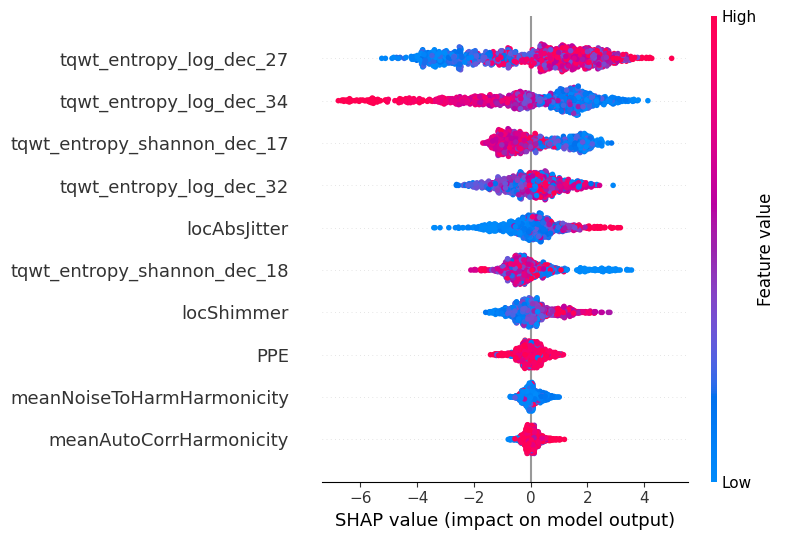

In [22]:
import shap

# Fit the XGBoost model
xgb_model.fit(X_resampled, y_resampled)

# Step 1: Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Step 2: Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_resampled)

# Step 3: Plot feature importance
shap.summary_plot(shap_values, X_resampled, feature_names=selected_features)


# Plot feature importance using XGBoost's built-in function


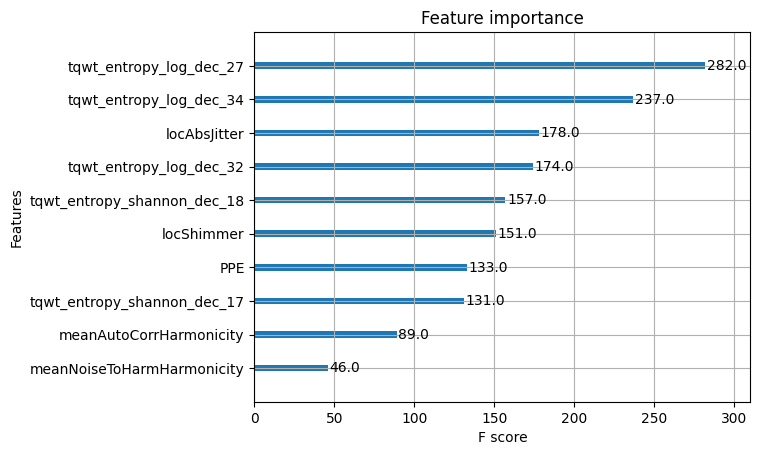

In [23]:
# Plot feature importance using XGBoost's built-in function
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10)
plt.show()


# Random SEARCH CV WITH RANDOMIZED SEARCH  ACCURACY 88%

In [18]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Define the parameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2, 0.3],
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Perform Randomized Search with Cross-Validation
random_search.fit(X_resampled, y_resampled)

# Get the best parameters and best score
best_params = random_search.best_params_
best_score = random_search.best_score_

# Print the best parameters and the best score
print("Best parameters found:", best_params)
print("Best cross-validation accuracy:", best_score)

# You can now train a final model with the best parameters:
best_xgb_model = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'subsample': 1.0, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best cross-validation accuracy: 0.8830009832841691


## Including more features not just the speech onces

# **FINAL CODE AND  REQUIRED WITH FINE FEAUTURES WITH OTHER SYMPTOM INCLUSION**

In [8]:
# prompt: create a model out of this

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

# Load your dataset
data = pd.read_csv('/content/pd_speech_features.csv')  # Update with your actual path

# Selected features from previous step
selected_features = ['PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer',
                     'meanNoiseToHarmHarmonicity', 'tqwt_entropy_shannon_dec_17',
                     'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',
                     'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18']

# Prepare the data
X = data[selected_features]
y = data['class']

# Step 1: Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Step 3: Train the XGBoost model with best parameters from the previous step (replace with your best parameters)
best_params = {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
xgb_model = xgb.XGBClassifier(**best_params, random_state=42)
xgb_model.fit(X_train, y_train)

# Step 4: Make predictions and evaluate the model
y_pred = xgb_model.predict(X_test)

# Print the results
print("XGBoost Model with SMOTE and Selected Features Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


XGBoost Model with SMOTE and Selected Features Accuracy: 0.911504424778761
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       165
           1       0.94      0.89      0.91       174

    accuracy                           0.91       339
   macro avg       0.91      0.91      0.91       339
weighted avg       0.91      0.91      0.91       339



# Mode preparation and testing

In [9]:
# prompt: extract model

import pickle

# Assuming 'xgb_model' is your trained XGBoost model
filename = 'xgb_model.pkl'  # Choose a filename for your model

# Save the model to a file
pickle.dump(xgb_model, open(filename, 'wb'))

# To load the model later:
# loaded_model = pickle.load(open(filename, 'rb'))


In [17]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the saved model
filename = 'xgb_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# 2. Prepare test data
selected_features = ['PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer',
                     'meanNoiseToHarmHarmonicity', 'tqwt_entropy_shannon_dec_17',
                     'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',
                     'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18']
                     # Replace with your actual selected features

y_test = data['class']  # Extract target variable
X_test = data.drop(columns=['class'])  # Remove target from features
X_test_selected = X_test[selected_features]  # Apply feature selection

# 3. Make predictions
y_pred = loaded_model.predict(X_test_selected)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9669
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       192
           1       0.99      0.96      0.98       564

    accuracy                           0.97       756
   macro avg       0.95      0.97      0.96       756
weighted avg       0.97      0.97      0.97       756



# Lets put it to test

In [37]:
import pandas as pd

# Step 1: Load your existing CSV file
df = pd.read_csv('/content/pd_speech_features.csv')  # Replace with your file path

# Step 2: Specify the selected features
selected_features = ['PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer',
                     'meanNoiseToHarmHarmonicity', 'tqwt_entropy_shannon_dec_17',
                     'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',
                     'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18','class']

# Step 3: Filter the DataFrame to only include the selected features
filtered_df = df[selected_features]

# Step 4: Save the filtered DataFrame to a new CSV file
filtered_df.to_csv('filtered_dataset.csv', index=False)

print("Filtered dataset saved successfully as 'filtered_dataset.csv'.")


Filtered dataset saved successfully as 'filtered_dataset.csv'.


In [39]:
import pandas as pd
import pickle

# 1. Load the saved model
filename = 'xgb_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# 2. Load your CSV file (replace with your file path)
data = pd.read_csv('/content/filtered_dataset.csv')

# 3. Prepare test data - select the first row for testing
selected_features = ['PPE', 'meanAutoCorrHarmonicity', 'locAbsJitter', 'locShimmer',
                     'meanNoiseToHarmHarmonicity', 'tqwt_entropy_shannon_dec_17',
                     'tqwt_entropy_log_dec_27', 'tqwt_entropy_log_dec_32',
                     'tqwt_entropy_log_dec_34', 'tqwt_entropy_shannon_dec_18']

# Extract a single row (you can choose other rows by changing the index)
X_test_single = data[selected_features].iloc[0:1]  # Get the first row of test data

# 4. Make a prediction for the single test case
y_pred_single = loaded_model.predict(X_test_single)

# 5. Output the result
print(f"Predicted class for the first test case: {y_pred_single[0]}")


Predicted class for the first test case: 1


In [40]:
import numpy as np
import pickle

# 1. Load the saved model
filename = 'xgb_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# 2. Manually input the values for the selected features
# Example input (replace these values with the ones you want to test)
input_values = np.array([[0.82127, 0.994753, 4.40E-06, 0.03564, 0.00531 ,978.2902 ,-11483.3723, -2922.2306 ,-2044.4926, 1308.8903]])

# 3. Make a prediction
y_pred_single = loaded_model.predict(input_values)

# 4. Output the result
print(f"Predicted class for the input values: {y_pred_single[0]}")


Predicted class for the input values: 0
